<a href="https://colab.research.google.com/github/AlwaysDageyra/Bille--initiative-/blob/main/test1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files

**importing the data**

In [36]:
uploaded=files.upload()

Saving student_cleaning_practice_200_v2.xlsx to student_cleaning_practice_200_v2 (1).xlsx


In [41]:
df1=pd.read_excel("student_cleaning_practice_200_v2.xlsx" , sep=";")

In [42]:
df1.head()

,student_id,name,age,gender,school,city,study_hours_per_day,attendance_percent,internet_access,parent_support,absences,exam_score,grade
0,STU034,Abdi Mohamed,19.0,Male,Bile Academy,Baidoa,4,87.0,No,No,3,69.0,C
1,STU086,Yusuf Yusuf,22.0,Male,Hodan School,Kismayo,5,87.0,No,No,0,98.0,A
2,STU057,Yusuf Hassan,18.0,Female,Hamar School,Baidoa,2,95.0,No,No,0,50.0,D
3,STU105,Hodan Yusuf,20.0,NaN,Bile Academy,Garowe,5,84.0,No,Yes,6,54.0,D
4,STU121,Ifrah Warsame,17.0,Male,Hamar School,Mogadishu,3,70.0,Yes,Yes,7,90.0,A


**checking the null values**

In [43]:
df1.isnull().sum()

,0
student_id,0
name,0
age,12
gender,10
school,0
city,8
study_hours_per_day,0
attendance_percent,11
internet_access,0
parent_support,0


we found 5 columns containing null values . 3 categoricals and one numerical

and then i handled the numerical columns using median

In [46]:
df1['age'].fillna(df1['age'].median(), inplace=True)
df1['attendance_percent'].fillna(df1['attendance_percent'].median(), inplace=True)
df1['exam_score'].fillna(df1['exam_score'].median(), inplace=True)

/tmp/ipykernel_663/3146957041.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['age'].fillna(df1['age'].median(), inplace=True)
/tmp/ipykernel_663/3146957041.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [47]:
df1.isnull().sum()

,0
student_id,0
name,0
age,0
gender,10
school,0
city,8
study_hours_per_day,0
attendance_percent,0
internet_access,0
parent_support,0


after that i handled the categorical columns using mode

In [48]:
df1['gender'].fillna(df1['gender'].mode()[0], inplace=True)
df1['city'].fillna(df1['city'].mode()[0], inplace=True)

/tmp/ipykernel_663/3572420132.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['gender'].fillna(df1['gender'].mode()[0], inplace=True)
/tmp/ipykernel_663/3572420132.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

checked and now there is no null values in my data

In [49]:
df1.isnull().sum()

,0
student_id,0
name,0
age,0
gender,0
school,0
city,0
study_hours_per_day,0
attendance_percent,0
internet_access,0
parent_support,0


checked the duplicated, found 10 duplicate values

In [50]:
df1.duplicated().sum()

np.int64(10)

droped the duplicates

In [51]:
df1.drop_duplicates(inplace=True)

now zero duplicates

In [52]:
df1.duplicated().sum()

np.int64(0)

In [44]:
df1.dtypes

,0
student_id,object
name,object
age,float64
gender,object
school,object
city,object
study_hours_per_day,int64
attendance_percent,float64
internet_access,object
parent_support,object


 Adding target feature "at_risk"

In [53]:
df1["at_risk"] = (df1["exam_score"] < 50).astype(int)

df1.head()

,student_id,name,age,gender,school,city,study_hours_per_day,attendance_percent,internet_access,parent_support,absences,exam_score,grade,at_risk
0,STU034,Abdi Mohamed,19.0,Male,Bile Academy,Baidoa,4,87.0,No,No,3,69.0,C,0
1,STU086,Yusuf Yusuf,22.0,Male,Hodan School,Kismayo,5,87.0,No,No,0,98.0,A,0
2,STU057,Yusuf Hassan,18.0,Female,Hamar School,Baidoa,2,95.0,No,No,0,50.0,D,0
3,STU105,Hodan Yusuf,20.0,Female,Bile Academy,Garowe,5,84.0,No,Yes,6,54.0,D,0
4,STU121,Ifrah Warsame,17.0,Male,Hamar School,Mogadishu,3,70.0,Yes,Yes,7,90.0,A,0


the i Selected model features and split into x (inputs) and y (target)

In [54]:
feature = [
    'study_hours_per_day', 'attendance_percent', 'internet_access',
    'parent_support', 'absences'
]

x = df1[feature].copy()
y = df1["at_risk"].copy()

then i checked the class balance of the target variable (at_risk)

In [55]:
y.value_counts()

,count
at_risk,
0,167
1,23


and then class  distribution using charts



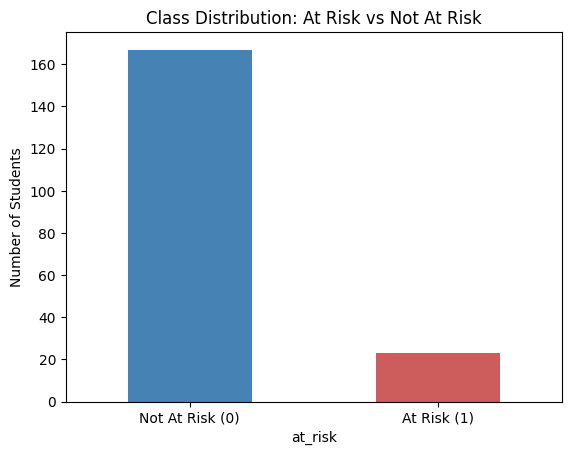

In [56]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar', color=['steelblue', 'indianred'])
plt.title('Class Distribution: At Risk vs Not At Risk')
plt.xlabel('at_risk')
plt.ylabel('Number of Students')
plt.xticks([0, 1], ['Not At Risk (0)', 'At Risk (1)'], rotation=0)
plt.show()